In [225]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder

df = pd.read_csv('data/Courses.csv')
df.head()

,index,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag
0,0,HarvardX/CB22x/2013_Spring,MHxPC130442623,1,0,0,0,United States,NaN,NaN,NaN,0,2012-12-19,2013-11-17,NaN,9.0,NaN,NaN,0,NaN,1.0
1,1,HarvardX/CS50x/2012,MHxPC130442623,1,1,0,0,United States,NaN,NaN,NaN,0,2012-10-15,NaN,NaN,9.0,NaN,1.0,0,NaN,1.0
2,2,HarvardX/CB22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0,2013-02-08,2013-11-17,NaN,16.0,NaN,NaN,0,NaN,1.0
3,3,HarvardX/CS50x/2012,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0,2012-09-17,NaN,NaN,16.0,NaN,NaN,0,NaN,1.0
4,4,HarvardX/ER22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0,2012-12-19,NaN,NaN,16.0,NaN,NaN,0,NaN,1.0


In [226]:
# 데이터 불러오기
df = pd.read_csv('./data/Courses.csv', parse_dates=['start_time_DI', 'last_event_DI'])
df.head()


,index,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,grade,start_time_DI,last_event_DI,nevents,ndays_act,nplay_video,nchapters,nforum_posts,roles,incomplete_flag
0,0,HarvardX/CB22x/2013_Spring,MHxPC130442623,1,0,0,0,United States,NaN,NaN,NaN,0,2012-12-19,2013-11-17,NaN,9.0,NaN,NaN,0,NaN,1.0
1,1,HarvardX/CS50x/2012,MHxPC130442623,1,1,0,0,United States,NaN,NaN,NaN,0,2012-10-15,NaT,NaN,9.0,NaN,1.0,0,NaN,1.0
2,2,HarvardX/CB22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0,2013-02-08,2013-11-17,NaN,16.0,NaN,NaN,0,NaN,1.0
3,3,HarvardX/CS50x/2012,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0,2012-09-17,NaT,NaN,16.0,NaN,NaN,0,NaN,1.0
4,4,HarvardX/ER22x/2013_Spring,MHxPC130275857,1,0,0,0,United States,NaN,NaN,NaN,0,2012-12-19,NaT,NaN,16.0,NaN,NaN,0,NaN,1.0


In [227]:
# 원본데이터 결측치 개수, 비율
display(pd.DataFrame({
    'sum': df.isna().sum(),
    'ratio': df.isna().mean() * 100
}).sort_values('ratio', ascending=False).reset_index())

,index,sum,ratio
0,roles,641138,100.000000
1,incomplete_flag,540977,84.377622
2,nplay_video,457530,71.362172
3,nchapters,258753,40.358394
4,nevents,199151,31.062111
5,last_event_DI,178954,27.911932
6,ndays_act,162743,25.383459
7,LoE_DI,106008,16.534350
8,YoB,96605,15.067739
9,gender,86806,13.539363


In [228]:
# 전처리용 데이터 셋 생성
pre = df.copy()

In [229]:
### 컬럼명 소문자화
pre.columns = pre.columns.str.lower()

In [230]:
# 중복행 확인
pre.duplicated().sum()

np.int64(0)

In [231]:
# 의미없는 컬럼 제거
pre = pre.drop(columns=['index', 'roles'])

In [232]:
#데이터 형변환
# grade 숫자형으로 변환
pre['grade'] = pd.to_numeric(pre['grade'], errors='coerce')

In [233]:
# 파생컬럼 생성

# 학생들의 나이(age) & (age_segment)
pre['age'] = pre['start_time_di'].dt.year - pre['yob']

pre['age_segment'] = np.select(
  [
    pre['age'].isna(),
    pre['age'] >= 60,
    pre['age'] >= 50,
    pre['age'] >= 40,
    pre['age'] >= 30,
    pre['age'] >= 20,
  ],
  [
    'unknown',
    '60s+',
    '50s',
    '40s',
    '30s',
    '20s',
  ],
  default='under 20'
)

# 퍼널 단계 컬럼(step): 각 학생 별 진행 단계
pre['step'] = np.select(
    [
        pre['certified'] ==1,
        pre['explored'] == 1,
        pre['viewed'] == 1,
        pre['registered'] == 1,
    ],
    [
        'c',
        'e',
        'v',
        'r'
    ],
    default='None'
)

# Missing Flag 컬럼 생성
missing_col = [
    'nchapters', 
    'nevents', 
    'ndays_act', 
    'nplay_video', 
    'last_event_di', 
    'age', 
    'grade']

for col in missing_col:
    pre[f'{col}_flag'] = pre[col].isna().astype(int)
    

# 학습 기간 (duration) 컬럼 생성
pre['duration'] = (pre['last_event_di'] - pre['start_time_di']).dt.days.astype(int, errors='ignore')+1


In [234]:
# 행제거
print('행 제거 작업 시작 전:')
print(pre.shape)

# 퍼널 논리적 오류 행 제거
funnel_mask1 = (pre['viewed'] == 0) & (pre['explored'] == 1)
funnel_mask2 = (pre['explored'] == 0) & (pre['certified'] == 1)
pre = pre[~funnel_mask1]
pre = pre[~funnel_mask2]

# durration 음수 행 제거
duration_mask = pre['duration'] < 0
pre = pre[~duration_mask]

# age 13세 미만 행 제거
age_mask = pre['age'] < 13
pre = pre[~age_mask]

# 상시 개방된 강의 제거 
course_mask = (pre['course_id'] =='HarvardX/CS50x/2012') | (pre['course_id'] =='HarvardX/ER22x/2013_Spring') | (pre['course_id'] =='HarvardX/CB22x/2013_Spring')
pre = pre[~course_mask]

# incomplete_flag == 1 제외
pre = pre[pre['incomplete_flag'].isna()]

# 논리적 오류 drop
rchap_mask = (pre['step']=='r') & ((pre['nchapters'] > 0)|(pre['nplay_video'] > 0))
pre = pre[~rchap_mask]

print('행 제거 작업 후:')
print(pre.shape)

행 제거 작업 시작 전:
(641138, 30)


C:\Users\my100\AppData\Local\Temp\ipykernel_14008\3049681768.py:9: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  pre = pre[~funnel_mask2]


행 제거 작업 후:
(354126, 30)


In [235]:
# 결측치 대체

# 성별 결측치(gender) : unknown 대체
pre['gender'] = pre['gender'].fillna('unknown')

# 학력 결측치(LoE_DI) : unknown 대체
pre['loe_di'] = pre['loe_di'].fillna('unknown')

# 탐색한 챕터 수 결측치(nchapters) : registered 단계일 때 0으로 대체
pre.loc[
  (pre['step']=='r') & (pre['nchapters'].isna()),
  'nchapters'
] = 0

# 탐색한 챕터 수 결측치(nchapters) : viewed 단계일 때 2로 대체
v_nchapters_median = pre.loc[
  (pre['step']=='v') & (pre['nchapters'].notna()),
  'nchapters'
].median()

pre.loc[
  (pre['step']=='v') & (pre['nchapters'].isna()),
  'nchapters'
] = v_nchapters_median

# 총 이벤트 발생 수 결측치(nevent) : registered 단계일 때 0으로 대체
pre.loc[
  (pre['step']=='r') & (pre['nevents'].isna()),
  'nevents'
] = 0

# # 활성 일수 결측치(ndays_act) : 0으로 대체
pre['ndays_act'] = pre['ndays_act'].fillna(0)

# 영상재생횟수(nplay_video) 결측치
pre.loc[
  (pre['nchapters']==0) & (pre['nplay_video'].isna()),
  'nplay_video'
] = 0

# 영상재생횟수 Viewed 단계 결측치 중앙값으로 대체
v_play_median = pre.loc[
  (pre['step']=='v') & (pre['nplay_video'].notna()),
  'nplay_video'
].median()

pre.loc[
  (pre['step']=='v') & (pre['nplay_video'].isna()),
  'nplay_video'
] = v_play_median

# 영상재생횟수 Explored 단계 결측치 중앙값으로 대체
e_play_median = pre.loc[
  (pre['step']=='e') & (pre['nplay_video'].notna()),
  'nplay_video'
].median()

pre.loc[
  (pre['step']=='e') & (pre['nplay_video'].isna()),
  'nplay_video'
] = e_play_median

# 영상재생횟수 Certified 단계 결측치 중앙값으로 대체
c_play_median = pre.loc[
  (pre['step']=='c') & (pre['nplay_video'].notna()),
  'nplay_video'
].median()

pre.loc[
  (pre['step']=='c') & (pre['nplay_video'].isna()),
  'nplay_video'
] = c_play_median

# 마지막 이벤트 발생일 (last_event_DI) : 논의중

# 나이 (age) 결측치 : 논의중

# 성적(grade) 결측치 : 논의중

# 강좌내 활동 기간 (duration)
pre['duration'] = pre['duration'].fillna(0)

In [236]:
# 강의별 공식 일정 테이블 생성 & merge

# 1. course_id별 공식 일정 매핑표
schedule_map = {
    # HarvardX
    'HarvardX/PH207x/2012_Fall': {
        'course_title': 'Health in Numbers: Quantitative Methods in Clinical & Public Health Research',
        'registration_open': '2012-07-24',
        'course_launch': '2012-10-15',
        'course_wrap': '2013-01-30'
    },
    'HarvardX/CS50x/2012': {
        'course_title': 'Introduction to Computer Science I',
        'registration_open': '2012-07-24',
        'course_launch': '2012-10-15',
                'course_wrap': '2013-04-15'
        },
        'HarvardX/ER22x/2013_Spring': {
                'course_title': 'Justice',
                'registration_open': '2012-12-19',
                'course_launch': '2013-03-02',
                'course_wrap': '2013-07-26'
        },
        'HarvardX/CB22x/2013_Spring': {
                'course_title': 'The Ancient Greek Hero',
                'registration_open': '2012-12-19',
                'course_launch': '2013-03-13',
                'course_wrap': '2013-08-26'
        },
        'HarvardX/PH278x/2013_Spring': {
                'course_title': 'Human Health and Global Environmental Change',
                'registration_open': '2012-12-19',
                'course_launch': '2013-05-15',
                'course_wrap': '2013-07-25'
        },

        # MITx
        'MITx/6.002x/2012_Fall': {
                'course_title': 'Circuits and Electronics - Fall',
                'registration_open': '2012-07-24',
                'course_launch': '2012-09-05',
                'course_wrap': '2012-12-25'
        },
        'MITx/6.00x/2012_Fall': {
                'course_title': 'Introduction to Computer Science and Programming - Fall',
                'registration_open': '2012-07-24',
                'course_launch': '2012-09-26',
                'course_wrap': '2013-01-15'
        },
        'MITx/3.091x/2012_Fall': {
                'course_title': 'Introduction to Solid State Chemistry - Fall',
                'registration_open': '2012-07-24',
                'course_launch': '2012-10-09',
                'course_wrap': '2013-01-15'
        },
        'MITx/6.00x/2013_Spring': {
                'course_title': 'Introduction to Computer Science and Programming - Spring',
                'registration_open': '2012-12-19',
                'course_launch': '2013-02-04',
                'course_wrap': '2013-06-04'
        },
        'MITx/3.091x/2013_Spring': {
                'course_title': 'Introduction to Solid State Chemistry - Spring',
                'registration_open': '2012-12-20',
                'course_launch': '2013-02-05',
                'course_wrap': '2013-06-21'
        },
        'MITx/14.73x/2013_Spring': {
                'course_title': 'The Challenges of Global Poverty',
                'registration_open': '2012-12-19',
                'course_launch': '2013-02-12',
                'course_wrap': '2013-05-21'
        },
        'MITx/8.02x/2013_Spring': {
                'course_title': 'Electricity and Magnetism',
                'registration_open': '2013-01-17',
                'course_launch': '2013-02-18',
                'course_wrap': '2013-06-18'
        },
        'MITx/6.002x/2013_Spring': {
                'course_title': 'Circuits and Electronics - Spring',
                'registration_open': '2012-12-20',
                'course_launch': '2013-03-03',
                'course_wrap': '2013-07-01'
        },
        'MITx/7.00x/2013_Spring': {
                'course_title': 'Introduction to Biology - The Secret of Life',
                'registration_open': '2013-01-30',
                'course_launch': '2013-03-05',
                'course_wrap': '2013-06-06'
        },
        'MITx/2.01x/2013_Spring': {
                'course_title': 'Elements of Structures',
                'registration_open': '2013-02-24',
                'course_launch': '2013-04-15',
                'course_wrap': '2013-07-30'
        },
        'MITx/8.MReV/2013_Summer': {
                'course_title': 'Mechanics ReView',
                'registration_open': '2013-04-27',
                'course_launch': '2013-06-01',
                'course_wrap': '2013-09-15'
        }
}

# 2. dict -> DataFrame 변환
schedule_df = (
        pd.DataFrame(schedule_map)
        .T
        .reset_index()
        .rename(columns={'index': 'course_id'})
)

# 3. 날짜형 변환
date_cols = ['registration_open', 'course_launch', 'course_wrap']
for col in date_cols:
        schedule_df[col] = pd.to_datetime(schedule_df[col])

# pre = pd.merge()
schedule_df

,course_id,course_title,registration_open,course_launch,course_wrap
0,HarvardX/PH207x/2012_Fall,Health in Numbers: Quantitative Methods in Cli...,2012-07-24,2012-10-15,2013-01-30
1,HarvardX/CS50x/2012,Introduction to Computer Science I,2012-07-24,2012-10-15,2013-04-15
2,HarvardX/ER22x/2013_Spring,Justice,2012-12-19,2013-03-02,2013-07-26
3,HarvardX/CB22x/2013_Spring,The Ancient Greek Hero,2012-12-19,2013-03-13,2013-08-26
4,HarvardX/PH278x/2013_Spring,Human Health and Global Environmental Change,2012-12-19,2013-05-15,2013-07-25
5,MITx/6.002x/2012_Fall,Circuits and Electronics - Fall,2012-07-24,2012-09-05,2012-12-25
6,MITx/6.00x/2012_Fall,Introduction to Computer Science and Programmi...,2012-07-24,2012-09-26,2013-01-15
7,MITx/3.091x/2012_Fall,Introduction to Solid State Chemistry - Fall,2012-07-24,2012-10-09,2013-01-15
8,MITx/6.00x/2013_Spring,Introduction to Computer Science and Programmi...,2012-12-19,2013-02-04,2013-06-04
9,MITx/3.091x/2013_Spring,Introduction to Solid State Chemistry - Spring,2012-12-20,2013-02-05,2013-06-21


In [237]:
# 2차 컬럼 drop
pre = pre.drop(columns=['yob', 'incomplete_flag'])

In [238]:
pre[(pre['ndays_act'].isna())&(pre['nevents'].notna())].shape

(0, 28)

In [239]:
pre['nplay_video'].isna().sum()

np.int64(0)

In [240]:
print(pre.loc[
    (pre['step']=='r')
    &(pre['nplay_video'].isna())
    ].info())

print(pre.loc[
    (pre['step']=='v')
    &(pre['nplay_video'].isna())
    ].info())
print(pre.loc[
    (pre['step']=='e')
    &(pre['nplay_video'].isna())
    ].info())
print(pre.loc[
    (pre['step']=='c')
    &(pre['nplay_video'].isna())
    ].info())

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 28 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   course_id           0 non-null      object        
 1   userid_di           0 non-null      object        
 2   registered          0 non-null      int64         
 3   viewed              0 non-null      int64         
 4   explored            0 non-null      int64         
 5   certified           0 non-null      int64         
 6   final_cc_cname_di   0 non-null      object        
 7   loe_di              0 non-null      object        
 8   gender              0 non-null      object        
 9   grade               0 non-null      float64       
 10  start_time_di       0 non-null      datetime64[ns]
 11  last_event_di       0 non-null      datetime64[ns]
 12  nevents             0 non-null      float64       
 13  ndays_act           0 non-null      float64       
 14  nplay_video

In [241]:
# 논리 기준에 안맞음 (드랍 예상)
step_v = pre.loc[
    (pre['step']=='v')
    #&(pre['nplay_video'].isna())
    #&(pre['nchapters'].notna())
]
# np.log1p(df["price"])

<Axes: xlabel='nplay_video', ylabel='Count'>

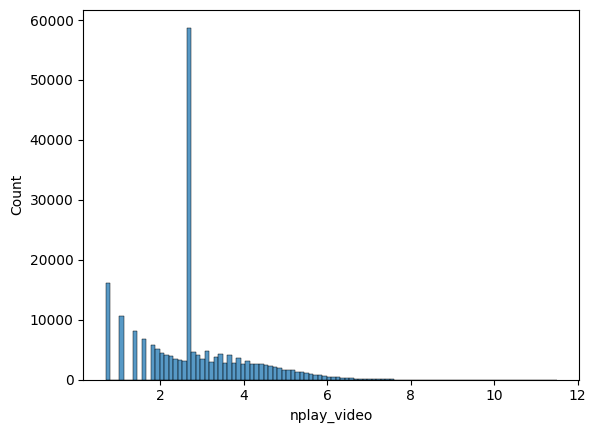

In [242]:
sns.histplot(np.log1p(step_v['nplay_video']), bins=100)

In [243]:

pre.info()

<class 'pandas.core.frame.DataFrame'>
Index: 354126 entries, 5 to 641136
Data columns (total 28 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   course_id           354126 non-null  object        
 1   userid_di           354126 non-null  object        
 2   registered          354126 non-null  int64         
 3   viewed              354126 non-null  int64         
 4   explored            354126 non-null  int64         
 5   certified           354126 non-null  int64         
 6   final_cc_cname_di   354126 non-null  object        
 7   loe_di              354126 non-null  object        
 8   gender              354126 non-null  object        
 9   grade               316724 non-null  float64       
 10  start_time_di       354126 non-null  datetime64[ns]
 11  last_event_di       324268 non-null  datetime64[ns]
 12  nevents             352358 non-null  float64       
 13  ndays_act           354126 non-nul

<Axes: xlabel='duration', ylabel='Count'>

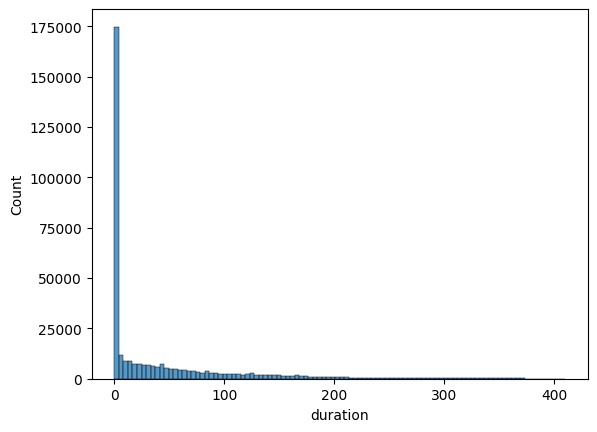

In [244]:
sns.histplot(pre['duration'], bins=100)

In [245]:
pre['duration'].isna().sum()

np.int64(0)

In [246]:
pre.columns

Index(['course_id', 'userid_di', 'registered', 'viewed', 'explored',
       'certified', 'final_cc_cname_di', 'loe_di', 'gender', 'grade',
       'start_time_di', 'last_event_di', 'nevents', 'ndays_act', 'nplay_video',
       'nchapters', 'nforum_posts', 'age', 'age_segment', 'step',
       'nchapters_flag', 'nevents_flag', 'ndays_act_flag', 'nplay_video_flag',
       'last_event_di_flag', 'age_flag', 'grade_flag', 'duration'],
      dtype='object')

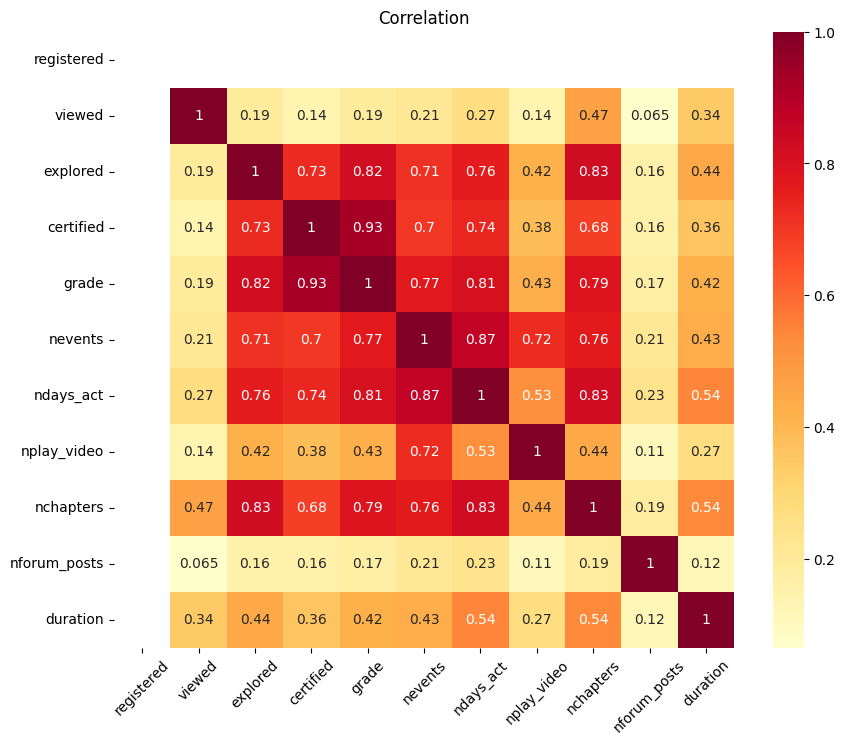

In [247]:
# 상관관계 분석 조합
cp_column = ['registered', 'viewed', 'explored',
       'certified', 'grade',
       'nevents', 'ndays_act', 'nplay_video',
       'nchapters', 'nforum_posts',
        'duration']
corr_matrix = pre[cp_column].corr()

# 히트맵 그리기
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='YlOrRd')
plt.title('Correlation')
plt.xticks(rotation=45)
plt.show()

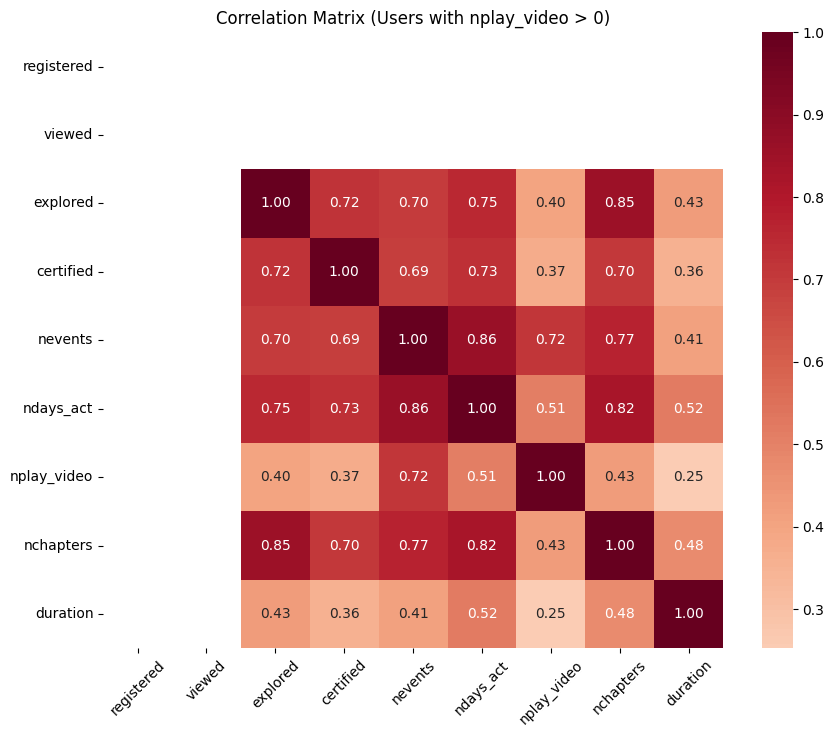

전체 유저 수: 354126
영상 시청 유저 수: 235226
영상 시청 유저 비중: 66.42%


In [248]:
# 1. 'nplay_video'가 0보다 큰 유저들만 추출 (필터링)
video_users = pre[pre['nplay_video'] > 0].copy()

# 2. 컬럼 선택
cols_to_corr = [
    'registered', 'viewed', 'explored', 'certified', 'nevents', 
    'ndays_act', 'nplay_video', 'nchapters', 'duration'
]

# 3. 상관계수 계산
video_corr = video_users[cols_to_corr].corr()

# 4. 히트맵 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(video_corr, annot=True, fmt=".2f", cmap='RdBu_r', center=0)
plt.title('Correlation Matrix (Users with nplay_video > 0)')
plt.xticks(rotation=45)
plt.show()

# 5. 데이터 변화 확인
print(f"전체 유저 수: {len(pre)}")
print(f"영상 시청 유저 수: {len(video_users)}")
print(f"영상 시청 유저 비중: {len(video_users) / len(pre):.2%}")

In [249]:
a = df.loc[
    (df['registered']== 1) &
    (df['viewed'] == 1) &
    (df['explored']==0) &
    (df['certified']==0) &
    (df['nplay_video'].notna()),
    'nplay_video']

print(a.shape)

b = df.loc[
    (df['registered']== 1) &
    (df['viewed'] == 0) &
    (df['explored']==0) &
    (df['certified']==0) &
    (df['nplay_video'].notna()),
    'nplay_video']

print(b.shape)

c = df.loc[
    (df['registered']== 1) &
    (df['viewed'] == 1) &
    (df['explored']==1) &
    (df['certified']==0) &
    (df['nplay_video'].notna()),
    'nplay_video']

print(c.shape)

d = df.loc[
    (df['registered']== 1) &
    (df['viewed'] == 1) &
    (df['explored']==1) &
    (df['certified']==1) &
    (df['nplay_video'].notna()),
    'nplay_video']

print(d.shape)

(159523,)
(126,)
(10653,)
(13139,)


In [250]:
import scipy.stats as stats
stat, p = stats.mannwhitneyu(a, b, alternative='two-sided')
print(stat, p)

stat_11, p_11 = stats.mannwhitneyu(a, c, alternative='two-sided')
print(stat_11, p_11)


16976027.5 5.577882808099059e-41
259867049.0 0.0


In [251]:
def cohens_d(x,y,stat):
    nx =len(x)
    ny =len(y)
    return 1 - (2*stat) / (nx*ny)

print(cohens_d(a,b, 16976027.5))
print(cohens_d(c,a, 259867049.0))

-0.6891655370589442
0.694165852100522


In [252]:
pd.set_option('display.max_columns', None)
pre.loc[(pre['duration']>=0)&(pre['nchapters'].notna())]

,course_id,userid_di,registered,viewed,explored,certified,final_cc_cname_di,loe_di,gender,grade,start_time_di,last_event_di,nevents,ndays_act,nplay_video,nchapters,nforum_posts,age,age_segment,step,nchapters_flag,nevents_flag,ndays_act_flag,nplay_video_flag,last_event_di_flag,age_flag,grade_flag,duration
5,HarvardX/PH207x/2012_Fall,MHxPC130275857,1,1,1,0,United States,unknown,unknown,0.0,2012-09-17,2013-05-23,502.0,16.0,50.0,12.0,0,NaN,unknown,e,0,0,0,0,0,1,0,249.0
15,HarvardX/PH207x/2012_Fall,MHxPC130024894,1,1,0,0,United States,unknown,unknown,0.0,2012-07-26,2013-01-16,75.0,14.0,5.0,2.0,0,NaN,unknown,v,0,0,0,0,0,1,0,175.0
16,HarvardX/PH278x/2013_Spring,MHxPC130024894,1,1,0,0,United States,unknown,unknown,0.0,2013-07-30,2013-08-27,11.0,2.0,2.0,1.0,0,NaN,unknown,v,0,0,0,0,0,1,0,29.0
18,HarvardX/PH207x/2012_Fall,MHxPC130080986,1,1,0,0,United States,unknown,unknown,0.0,2012-10-25,2012-12-04,56.0,11.0,1.0,2.0,1,NaN,unknown,v,0,0,0,0,0,1,0,41.0
39,HarvardX/PH278x/2013_Spring,MHxPC130435030,1,0,0,0,Canada,unknown,unknown,0.0,2013-02-20,2013-05-20,2.0,1.0,0.0,0.0,0,NaN,unknown,r,1,0,0,1,0,1,0,90.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641132,MITx/6.002x/2013_Spring,MHxPC130030805,1,1,0,0,Pakistan,Master's,m,NaN,2013-09-07,2013-09-07,29.0,1.0,14.0,1.0,0,24.0,20s,v,0,0,0,1,0,0,1,1.0
641133,MITx/6.00x/2013_Spring,MHxPC130184108,1,1,0,0,Canada,Bachelor's,m,NaN,2013-09-07,2013-09-07,97.0,1.0,4.0,2.0,0,22.0,20s,v,0,0,0,0,0,0,1,1.0
641134,MITx/6.00x/2013_Spring,MHxPC130359782,1,0,0,0,Other Europe,Bachelor's,f,NaN,2013-09-07,2013-09-07,1.0,1.0,0.0,0.0,0,22.0,20s,r,1,0,0,1,0,0,1,1.0
641135,MITx/6.002x/2013_Spring,MHxPC130098513,1,0,0,0,United States,Doctorate,m,NaN,2013-09-07,2013-09-07,1.0,1.0,0.0,0.0,0,34.0,30s,r,1,0,0,1,0,0,1,1.0


In [253]:
pre['nevents'].isna().sum()

np.int64(1768)

- 전환율
    - view_rate = viewed / registered
    - explore_rate = explored / viewed
    - certi_rate = certified / explored
- 참여도가 높고 낮은 학생
    - evnets_per_day = nevents/ ndays_act (일당 활동량)
    - video_ratio = nplay_video / nevents (비디오 학습 비중)
- 활동별 성취도
    - video_per_day = nplay_video / ndays_act
    - forum_per_day = nforum_posts / ndays_act
    - chapter_per_day = nchapters / ndays_act
- 시간 지표
    - active_density = ndays_act / duration
    - 코스별 수료 기간 = 기간중 certified(step) 까지 걸린 (평균)시간
    - pre = pd.merge(pre, course_avg_duration, on='course_id', how='left') 
- 코스 기간(schedule_df)
    - 코스별 강좌 개설 시간 = course_launch - course_wrap
- 총 강의 개수

In [254]:
# 코스별 수료 기간 = 기간중 certified(step) 까지 걸린 (평균)시간

certified_users = pre[pre['certified'] == 1].copy()

# 코스별로 수료자들의 평균 duration 계산
course_avg_duration = certified_users.groupby('course_id')['duration'].mean().reset_index()

# 컬럼명 변경 (구분을 위해)
course_avg_duration.columns = ['course_id', 'avg_completion_days']
course_avg_duration

,course_id,avg_completion_days
0,HarvardX/PH207x/2012_Fall,157.550843
1,HarvardX/PH278x/2013_Spring,145.897959
2,MITx/14.73x/2013_Spring,125.628434
3,MITx/2.01x/2013_Spring,127.581301
4,MITx/3.091x/2012_Fall,177.006329
5,MITx/3.091x/2013_Spring,159.906542
6,MITx/6.002x/2012_Fall,182.461627
7,MITx/6.002x/2013_Spring,150.823427
8,MITx/6.00x/2012_Fall,187.243155
9,MITx/6.00x/2013_Spring,154.479233


In [255]:
# pre['duration'] = (pre['last_event_di'] - pre['start_time_di']).dt.days.astype(int, errors='ignore')
# pre = pd.merge(pre, course_avg_duration, on='course_id', how='left')
schedule_df['sc_duration'] = (schedule_df['course_wrap'] - schedule_df['course_launch']).dt.days.astype(int, errors='ignore')
schedule_df['reg_duration'] = (schedule_df['course_wrap'] - schedule_df['registration_open']).dt.days.astype(int, errors='ignore')


schedule_df = pd.merge(schedule_df, course_avg_duration, on= 'course_id', how='left')
schedule_df

,course_id,course_title,registration_open,course_launch,course_wrap,sc_duration,reg_duration,avg_completion_days
0,HarvardX/PH207x/2012_Fall,Health in Numbers: Quantitative Methods in Cli...,2012-07-24,2012-10-15,2013-01-30,107,190,157.550843
1,HarvardX/CS50x/2012,Introduction to Computer Science I,2012-07-24,2012-10-15,2013-04-15,182,265,NaN
2,HarvardX/ER22x/2013_Spring,Justice,2012-12-19,2013-03-02,2013-07-26,146,219,NaN
3,HarvardX/CB22x/2013_Spring,The Ancient Greek Hero,2012-12-19,2013-03-13,2013-08-26,166,250,NaN
4,HarvardX/PH278x/2013_Spring,Human Health and Global Environmental Change,2012-12-19,2013-05-15,2013-07-25,71,218,145.897959
5,MITx/6.002x/2012_Fall,Circuits and Electronics - Fall,2012-07-24,2012-09-05,2012-12-25,111,154,182.461627
6,MITx/6.00x/2012_Fall,Introduction to Computer Science and Programmi...,2012-07-24,2012-09-26,2013-01-15,111,175,187.243155
7,MITx/3.091x/2012_Fall,Introduction to Solid State Chemistry - Fall,2012-07-24,2012-10-09,2013-01-15,98,175,177.006329
8,MITx/6.00x/2013_Spring,Introduction to Computer Science and Programmi...,2012-12-19,2013-02-04,2013-06-04,120,167,154.479233
9,MITx/3.091x/2013_Spring,Introduction to Solid State Chemistry - Spring,2012-12-20,2013-02-05,2013-06-21,136,183,159.906542


In [256]:
course_mask1 = (schedule_df['course_id'] =='HarvardX/CS50x/2012') | (schedule_df['course_id'] =='HarvardX/ER22x/2013_Spring') | (schedule_df['course_id'] =='HarvardX/CB22x/2013_Spring')
schedule_df = schedule_df[~course_mask1].reset_index(drop=True)
schedule_df

,course_id,course_title,registration_open,course_launch,course_wrap,sc_duration,reg_duration,avg_completion_days
0,HarvardX/PH207x/2012_Fall,Health in Numbers: Quantitative Methods in Cli...,2012-07-24,2012-10-15,2013-01-30,107,190,157.550843
1,HarvardX/PH278x/2013_Spring,Human Health and Global Environmental Change,2012-12-19,2013-05-15,2013-07-25,71,218,145.897959
2,MITx/6.002x/2012_Fall,Circuits and Electronics - Fall,2012-07-24,2012-09-05,2012-12-25,111,154,182.461627
3,MITx/6.00x/2012_Fall,Introduction to Computer Science and Programmi...,2012-07-24,2012-09-26,2013-01-15,111,175,187.243155
4,MITx/3.091x/2012_Fall,Introduction to Solid State Chemistry - Fall,2012-07-24,2012-10-09,2013-01-15,98,175,177.006329
5,MITx/6.00x/2013_Spring,Introduction to Computer Science and Programmi...,2012-12-19,2013-02-04,2013-06-04,120,167,154.479233
6,MITx/3.091x/2013_Spring,Introduction to Solid State Chemistry - Spring,2012-12-20,2013-02-05,2013-06-21,136,183,159.906542
7,MITx/14.73x/2013_Spring,The Challenges of Global Poverty,2012-12-19,2013-02-12,2013-05-21,98,153,125.628434
8,MITx/8.02x/2013_Spring,Electricity and Magnetism,2013-01-17,2013-02-18,2013-06-18,120,152,165.114495
9,MITx/6.002x/2013_Spring,Circuits and Electronics - Spring,2012-12-20,2013-03-03,2013-07-01,120,193,150.823427


In [257]:
schedule_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   course_id            13 non-null     object        
 1   course_title         13 non-null     object        
 2   registration_open    13 non-null     datetime64[ns]
 3   course_launch        13 non-null     datetime64[ns]
 4   course_wrap          13 non-null     datetime64[ns]
 5   sc_duration          13 non-null     int64         
 6   reg_duration         13 non-null     int64         
 7   avg_completion_days  13 non-null     float64       
dtypes: datetime64[ns](3), float64(1), int64(2), object(2)
memory usage: 964.0+ bytes


In [260]:
schedule_df['reg_avg'] = schedule_df['reg_duration'] - schedule_df['avg_completion_days']
schedule_df['sc_avg'] = schedule_df['sc_duration'] - schedule_df['avg_completion_days']
schedule_df

,course_id,course_title,registration_open,course_launch,course_wrap,sc_duration,reg_duration,avg_completion_days,reg_avg,sc_avg
0,HarvardX/PH207x/2012_Fall,Health in Numbers: Quantitative Methods in Cli...,2012-07-24,2012-10-15,2013-01-30,107,190,157.550843,32.449157,-50.550843
1,HarvardX/PH278x/2013_Spring,Human Health and Global Environmental Change,2012-12-19,2013-05-15,2013-07-25,71,218,145.897959,72.102041,-74.897959
2,MITx/6.002x/2012_Fall,Circuits and Electronics - Fall,2012-07-24,2012-09-05,2012-12-25,111,154,182.461627,-28.461627,-71.461627
3,MITx/6.00x/2012_Fall,Introduction to Computer Science and Programmi...,2012-07-24,2012-09-26,2013-01-15,111,175,187.243155,-12.243155,-76.243155
4,MITx/3.091x/2012_Fall,Introduction to Solid State Chemistry - Fall,2012-07-24,2012-10-09,2013-01-15,98,175,177.006329,-2.006329,-79.006329
5,MITx/6.00x/2013_Spring,Introduction to Computer Science and Programmi...,2012-12-19,2013-02-04,2013-06-04,120,167,154.479233,12.520767,-34.479233
6,MITx/3.091x/2013_Spring,Introduction to Solid State Chemistry - Spring,2012-12-20,2013-02-05,2013-06-21,136,183,159.906542,23.093458,-23.906542
7,MITx/14.73x/2013_Spring,The Challenges of Global Poverty,2012-12-19,2013-02-12,2013-05-21,98,153,125.628434,27.371566,-27.628434
8,MITx/8.02x/2013_Spring,Electricity and Magnetism,2013-01-17,2013-02-18,2013-06-18,120,152,165.114495,-13.114495,-45.114495
9,MITx/6.002x/2013_Spring,Circuits and Electronics - Spring,2012-12-20,2013-03-03,2013-07-01,120,193,150.823427,42.176573,-30.823427


In [263]:
pre = pd.merge(pre, schedule_df[['course_id','registration_open','course_launch','course_wrap','sc_duration','reg_duration','avg_completion_days','reg_avg','sc_avg']], on='course_id', how='left')

In [264]:
pre.head()

,course_id,userid_di,registered,viewed,explored,certified,final_cc_cname_di,loe_di,gender,grade,start_time_di,last_event_di,nevents,ndays_act,nplay_video,nchapters,nforum_posts,age,age_segment,step,nchapters_flag,nevents_flag,ndays_act_flag,nplay_video_flag,last_event_di_flag,age_flag,grade_flag,duration,registration_open,course_launch,course_wrap,sc_duration,reg_duration,avg_completion_days,reg_avg,sc_avg
0,HarvardX/PH207x/2012_Fall,MHxPC130275857,1,1,1,0,United States,unknown,unknown,0.0,2012-09-17,2013-05-23,502.0,16.0,50.0,12.0,0,NaN,unknown,e,0,0,0,0,0,1,0,249.0,2012-07-24,2012-10-15,2013-01-30,107,190,157.550843,32.449157,-50.550843
1,HarvardX/PH207x/2012_Fall,MHxPC130024894,1,1,0,0,United States,unknown,unknown,0.0,2012-07-26,2013-01-16,75.0,14.0,5.0,2.0,0,NaN,unknown,v,0,0,0,0,0,1,0,175.0,2012-07-24,2012-10-15,2013-01-30,107,190,157.550843,32.449157,-50.550843
2,HarvardX/PH278x/2013_Spring,MHxPC130024894,1,1,0,0,United States,unknown,unknown,0.0,2013-07-30,2013-08-27,11.0,2.0,2.0,1.0,0,NaN,unknown,v,0,0,0,0,0,1,0,29.0,2012-12-19,2013-05-15,2013-07-25,71,218,145.897959,72.102041,-74.897959
3,HarvardX/PH207x/2012_Fall,MHxPC130080986,1,1,0,0,United States,unknown,unknown,0.0,2012-10-25,2012-12-04,56.0,11.0,1.0,2.0,1,NaN,unknown,v,0,0,0,0,0,1,0,41.0,2012-07-24,2012-10-15,2013-01-30,107,190,157.550843,32.449157,-50.550843
4,HarvardX/PH278x/2013_Spring,MHxPC130435030,1,0,0,0,Canada,unknown,unknown,0.0,2013-02-20,2013-05-20,2.0,1.0,0.0,0.0,0,NaN,unknown,r,1,0,0,1,0,1,0,90.0,2012-12-19,2013-05-15,2013-07-25,71,218,145.897959,72.102041,-74.897959


In [277]:
pre.loc[(pre['ndays_act']==0) & (pre['nplay_video']>0)&(pre['nchapters']>0), 'viewed'].value_counts()

viewed
1    1768
Name: count, dtype: int64

In [285]:
pre.loc[(pre['ndays_act'].notna()) & (pre['nplay_video']>0)&(pre['nchapters']>0)&(pre['viewed']==1)]['ndays_act'].describe()

count    235226.000000
mean          8.243141
std          14.943518
min           0.000000
25%           1.000000
50%           3.000000
75%           7.000000
max         205.000000
Name: ndays_act, dtype: float64

In [276]:
pre.loc[(pre['step']=='r') & ((pre['nchapters']>0)|(pre['nplay_video']>0))]

,course_id,userid_di,registered,viewed,explored,certified,final_cc_cname_di,loe_di,gender,grade,start_time_di,last_event_di,nevents,ndays_act,nplay_video,nchapters,nforum_posts,age,age_segment,step,nchapters_flag,nevents_flag,ndays_act_flag,nplay_video_flag,last_event_di_flag,age_flag,grade_flag,duration,registration_open,course_launch,course_wrap,sc_duration,reg_duration,avg_completion_days,reg_avg,sc_avg


In [297]:
pre.loc[(pre['nplay_video'].notna()) &(pre['nchapters'].notna()) & (pre['step']=='v'), 'viewed'].value_counts()

viewed
1    210700
Name: count, dtype: int64

In [295]:
pre[pre['step']=='v'].info()

<class 'pandas.core.frame.DataFrame'>
Index: 210700 entries, 1 to 354125
Data columns (total 36 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   course_id            210700 non-null  object        
 1   userid_di            210700 non-null  object        
 2   registered           210700 non-null  int64         
 3   viewed               210700 non-null  int64         
 4   explored             210700 non-null  int64         
 5   certified            210700 non-null  int64         
 6   final_cc_cname_di    210700 non-null  object        
 7   loe_di               210700 non-null  object        
 8   gender               210700 non-null  object        
 9   grade                190085 non-null  float64       
 10  start_time_di        210700 non-null  datetime64[ns]
 11  last_event_di        208932 non-null  datetime64[ns]
 12  nevents              208932 non-null  float64       
 13  ndays_act          

In [298]:
pre[pre['step']=='v'].isna().sum().sort_values(ascending=False)

age                    37547
grade                  20615
last_event_di           1768
nevents                 1768
viewed                     0
registered                 0
userid_di                  0
course_id                  0
loe_di                     0
final_cc_cname_di          0
explored                   0
certified                  0
start_time_di              0
gender                     0
nplay_video                0
ndays_act                  0
nchapters                  0
nforum_posts               0
age_segment                0
step                       0
nchapters_flag             0
nevents_flag               0
ndays_act_flag             0
nplay_video_flag           0
last_event_di_flag         0
age_flag                   0
grade_flag                 0
duration                   0
registration_open          0
course_launch              0
course_wrap                0
sc_duration                0
reg_duration               0
avg_completion_days        0
reg_avg       

In [299]:
pre[pre['viewed']==1].isna().sum().sort_values(ascending=False)

age                    43264
grade                  21263
last_event_di           1768
nevents                 1768
viewed                     0
registered                 0
userid_di                  0
course_id                  0
loe_di                     0
final_cc_cname_di          0
explored                   0
certified                  0
start_time_di              0
gender                     0
nplay_video                0
ndays_act                  0
nchapters                  0
nforum_posts               0
age_segment                0
step                       0
nchapters_flag             0
nevents_flag               0
ndays_act_flag             0
nplay_video_flag           0
last_event_di_flag         0
age_flag                   0
grade_flag                 0
duration                   0
registration_open          0
course_launch              0
course_wrap                0
sc_duration                0
reg_duration               0
avg_completion_days        0
reg_avg       

In [300]:
pre['age'].mean()

np.float64(26.645321130726742)